# XAI vs No XAI Comparison - IC50 MPro Task

Comparing the effect of explainable AI (XAI) guidance on molecule optimization performance for IC50 prediction against SARS-CoV-2 Main Protease (MPro).

**Note**: For IC50, lower values are better. Only molecules with QED ≥ 0.6 are considered valid; molecules below this threshold are assigned a penalty score.


In [51]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random 

random.seed(42)
np.random.seed(42)


In [52]:
# Define paths
RESULTS_DIR = Path("../../data/results/ic50mpro_qed")

# Set to False to hide legend (for combined figures with shared legend)
SHOW_LEGEND = True

# Penalty value for molecules with QED < 0.6 (in nM)
# Using 1,000,000 nM (1 mM) as a high but finite penalty
QED_PENALTY_IC50 = 1_000_000
QED_THRESHOLD = 0.6

# Define experiment groups: (display_name, folder_name)
GROUPS = [
    ("Claude Opus 4.5 (Full XAI)", "claude-opus-4.5_full_xai"),
    ("Claude Opus 4.5 (Partial XAI)", "claude-opus-4.5_partial_xai"),
    ("Claude Opus 4.5 (No XAI)", "claude-opus-4.5_no_xai"),
    ("Claude Opus 4.5 (No description)", "claude-opus-4.5_no_description"),
    ("REINVENT", "reinvent"),
    ("GraphGA", "graph_ga"),
    ("GP-BO", "gpbo"),
]


## Loading Data


In [53]:
def load_trace(p: Path) -> list:
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d


def load_results_as_df(results_dir: Path, groups: list, qed_threshold: float, penalty: float) -> pd.DataFrame:
    """Load all results from JSON trace files into a DataFrame.
    
    For molecules with QED < qed_threshold, the IC50 score is replaced with a penalty value.
    
    Returns DataFrame with columns: model, replicate, iteration, score, effective_score, qed, smiles
    """
    rows = []
    
    for display_name, folder_name in groups:
        folder_path = results_dir / folder_name
        files = sorted(folder_path.glob("ic50mpro_qed_*.json"))
        
        if not files:
            print(f"Warning: No files in {folder_path} matching ic50mpro_qed_*.json")
            continue
        
        for file_path in files:
            # Extract replicate number from filename (e.g., "rep1", "rep2")
            rep_match = re.search(r'rep(\d+)', file_path.name)
            replicate = int(rep_match.group(1)) if rep_match else 0
            
            try:
                trace = load_trace(file_path)
                for entry in trace:
                    ic50_score = float(entry["score"])
                    qed = float(entry["scores"]["QED"])
                    
                    # Apply penalty for molecules with QED below threshold
                    effective_score = ic50_score if qed >= qed_threshold else penalty
                    
                    rows.append({
                        "model": display_name,
                        "replicate": replicate,
                        "iteration": int(entry["iteration"]),
                        "score": ic50_score,
                        "effective_score": effective_score,
                        "qed": qed,
                        "smiles": entry["smiles"],
                    })
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return pd.DataFrame(rows)


# Load all results
df = load_results_as_df(RESULTS_DIR, GROUPS, QED_THRESHOLD, QED_PENALTY_IC50)


---
## Best-so-far Progression Plot

For IC50 (lower is better), we use cumulative minimum. Molecules with QED < 0.6 are assigned a penalty score.


> **Note on baselines:** With only 50 oracle calls, REINVENT / GraphGA / GP-BO never complete their initialization phase (default population sizes: GraphGA=120, GP-BO=340). These curves therefore represent **random sampling from a drug-like (ZINC) library**, not actual algorithm optimization. Treat them as a random-search lower bound, not as representative of these algorithms' capabilities.

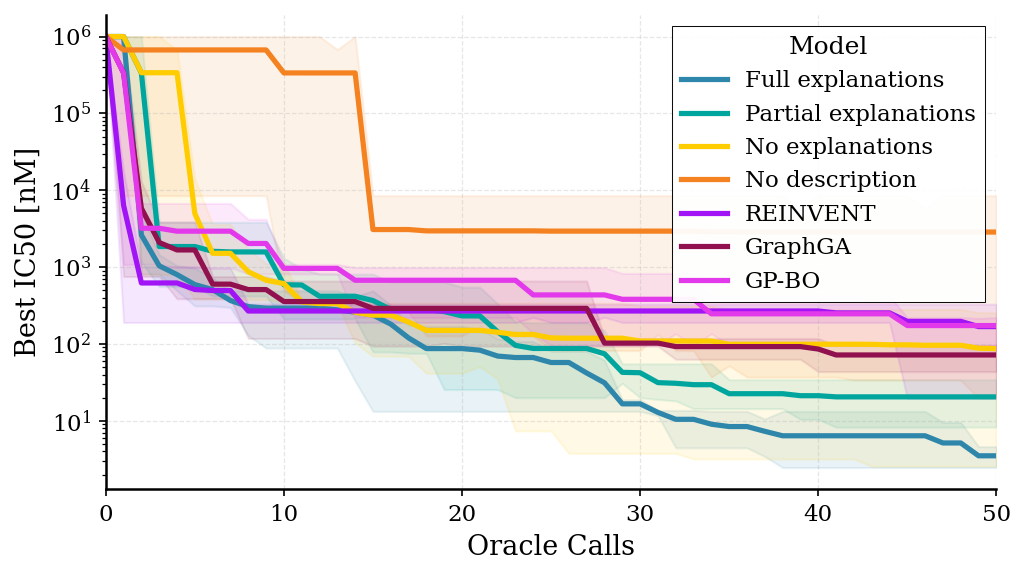

In [54]:
# Compute best-so-far using cummin (for IC50, lower is better)
# Using effective_score which has penalty applied for QED < threshold
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "replicate"])["effective_score"]
    .cummin()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(0, max_iter + 1)
df_plot = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "replicate"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .fillna(QED_PENALTY_IC50)  # Baseline at oracle call 0 (worst case penalty)
    .melt(ignore_index=False)
    .reset_index()
)

# Set publication-quality style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.figsize': (6, 4),
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.6,
    'lines.linewidth': 2.5,
})

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

# Define color palette for explanation conditions
model_colors = {
    'Claude Opus 4.5 (Full XAI)': '#2E86AB',
    'Claude Opus 4.5 (Partial XAI)': '#00a69d',
    'Claude Opus 4.5 (No XAI)': '#ffcc00',
    'Claude Opus 4.5 (No description)': '#f58220',
    'REINVENT': '#A014F5',
    'GraphGA': "#91114F",
    'GP-BO': "#E239EB",
}

# Define legend order and labels
legend_order = [
    'Claude Opus 4.5 (Full XAI)',
    'Claude Opus 4.5 (Partial XAI)',
    'Claude Opus 4.5 (No XAI)',
    'Claude Opus 4.5 (No description)',
    'REINVENT',
    'GraphGA',
    'GP-BO',
]

legend_labels = {
    'Claude Opus 4.5 (Full XAI)': 'Full explanations',
    'Claude Opus 4.5 (Partial XAI)': 'Partial explanations',
    'Claude Opus 4.5 (No XAI)': 'No explanations',
    'Claude Opus 4.5 (No description)': 'No description',
    'REINVENT': 'REINVENT',
    'GraphGA': 'GraphGA',
    'GP-BO': 'GP-BO',
}

# Plot with seaborn (mean + 95% bootstrap CI)
sns.lineplot(
    data=df_plot, 
    x="iteration", 
    y="value", 
    hue="model",
    hue_order=legend_order,
    palette=model_colors,
    errorbar=('ci', 95),
    err_kws={'alpha': 0.1},  # Make confidence interval more transparent
    linewidth=2.5,
    ax=ax
)

# Styling
ax.set_xlabel("Oracle Calls", fontsize=13, fontweight='normal')
ax.set_ylabel("Best IC50 [nM]", fontsize=13, fontweight='normal')
ax.set_xlim(0, 50)
# Use log scale for IC50 as values can span several orders of magnitude
ax.set_yscale('log')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Conditionally show/hide legend
if SHOW_LEGEND:
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [legend_labels.get(label, label) for label in labels]
    legend = ax.legend(
        handles,
        new_labels,
        title='Model',
        frameon=True,
        fancybox=False,
        shadow=False,
        framealpha=0.95,
        edgecolor='black',
        loc='upper right'
    )
    legend.get_frame().set_linewidth(0.5)
else:
    ax.get_legend().remove()

plt.tight_layout()

# Save figure as PDF
plt.savefig('./figures/xai_vs_no_xai_ic50mpro_extended.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()


---
## Iteration to Reach IC50 Threshold

Finding the first iteration where the best-so-far IC50 drops below a target threshold (only for molecules with QED ≥ 0.6).


In [55]:
# Target IC50 threshold in nM (lower is better)
IC50_THRESHOLD = 100  # nM

def first_iteration_below_threshold(group, threshold=IC50_THRESHOLD):
    """Return first iteration where best_so_far <= threshold, or NaN if never reached.
    
    For IC50, lower is better, so we check for values BELOW the threshold.
    """
    below = group[group["best_so_far"] <= threshold]
    if len(below) > 0:
        return below["iteration"].min()
    return np.nan


def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) < 2:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,), 
        statistic=np.mean, 
        n_resamples=n_bootstrap, 
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high


# Compute for each model and replicate
iter_to_threshold = (
    df
    .groupby(["model", "replicate"])
    .apply(first_iteration_below_threshold, include_groups=False)
    .reset_index(name="iter_to_threshold")
)

# Summarize by model with bootstrap CI
summary_rows = []
for model, group in iter_to_threshold.groupby("model"):
    values = group["iter_to_threshold"]
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    n_total = len(values)
    never_reached = values.isna().sum()
    success_rate = (n_total - never_reached) / n_total * 100
    summary_rows.append({
        "Model": model,
        "Mean Iteration": mean_val,
        "CI 95% Low": ci_low,
        "CI 95% High": ci_high,
        "N": n_total,
        "Never Reached": never_reached,
        "Success Rate (%)": success_rate
    })

threshold_summary = pd.DataFrame(summary_rows).set_index("Model").round(2)

print(f"Iteration to reach IC50 ≤ {IC50_THRESHOLD} nM threshold (with QED ≥ {QED_THRESHOLD}) — 95% Bootstrap CI")
threshold_summary


Iteration to reach IC50 ≤ 100 nM threshold (with QED ≥ 0.6) — 95% Bootstrap CI


,Mean Iteration,CI 95% Low,CI 95% High,N,Never Reached,Success Rate (%)
Model,,,,,,
Claude Opus 4.5 (Full XAI),17.33,9.0,25.0,3,0,100.00
Claude Opus 4.5 (No XAI),16.50,15.0,18.0,3,1,66.67
Claude Opus 4.5 (No description),29.50,25.0,34.0,3,1,66.67
Claude Opus 4.5 (Partial XAI),22.00,15.0,29.0,3,0,100.00
GP-BO,24.00,NaN,NaN,3,2,33.33
GraphGA,28.00,15.0,41.0,3,0,100.00
REINVENT,45.00,NaN,NaN,3,2,33.33


---
## AUC Top-1 of pIC50 values over 50 Iterations


In [56]:
# --- AUC Top-1 on pIC50 scale (best-so-far over 50 oracle calls) ---
# pIC50 = -log10(IC50 in M) = 9 - log10(IC50 in nM); HIGHER is better.
# Unlike the nM-AUC above (computed in linear space, dominated by the worst values),
# the AUC of best-so-far pIC50 weights improvements on a log scale automatically and
# needs no arbitrary success threshold. QED < threshold molecules gets a score of 0 (no valid molecule found yet)


def ic50_nm_to_pic50(ic50_nm):
    """Convert IC50 in nM to pIC50 = -log10(IC50 in M)."""
    return 9.0 - np.log10(ic50_nm)

MAX_ORACLE_CALLS = 50
PIC50_PENALTY = 0

def compute_auc_top1_pic50(group_df, max_oracle_calls=50, penalty_pic50=PIC50_PENALTY):
    """Compute normalized AUC of top-1 (best) pIC50 vs oracle calls for a single run.

    For pIC50, higher is better, so we track the cumulative MAXIMUM. The AUC is the
    area under the best-so-far step curve, normalized by max_oracle_calls, i.e. the
    mean best-so-far pIC50 over the budget. Higher is better.
    """
    sorted_df = group_df.sort_values('iteration')

    best_pic50 = penalty_pic50  # start at floor (worst case) before any valid molecule
    best_at_call = {}

    for _, row in sorted_df.iterrows():
        oracle_call = int(row['iteration'])
        if oracle_call > max_oracle_calls:
            break
        pic50 = ic50_nm_to_pic50(float(row['effective_score']))
        if pic50 > best_pic50:
            best_pic50 = pic50
        best_at_call[oracle_call] = best_pic50

    if not best_at_call:
        return penalty_pic50  

    # Left Riemann sum over the step function, extended to max_oracle_calls.
    auc = 0.0
    prev_call = 0
    prev_best = penalty_pic50
    for call in sorted(best_at_call.keys()):
        auc += prev_best * (call - prev_call)
        prev_call = call
        prev_best = best_at_call[call]
    auc += prev_best * (max_oracle_calls - prev_call)

    # Normalize -> mean best-so-far pIC50 over the budget
    return auc / max_oracle_calls


# Compute AUC Top-1 (pIC50) for each model/replicate
auc_pic50_records = []
for (model, replicate), group in df.groupby(['model', 'replicate']):
    auc_pic50_records.append({
        'model': model,
        'replicate': replicate,
        'auc_top1_pic50': compute_auc_top1_pic50(group, MAX_ORACLE_CALLS),
    })

auc_pic50_df = pd.DataFrame(auc_pic50_records)

# Summarize by model with bootstrap CI
auc_pic50_summary_rows = []
for model, group in auc_pic50_df.groupby('model'):
    values = group['auc_top1_pic50']
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    auc_pic50_summary_rows.append({
        "Model": model,
        "Mean AUC Top-1 (pIC50)": mean_val,
        "CI 95% -": mean_val - ci_low,
        "CI 95% +": ci_high - mean_val,
        "N": len(values),
    })

auc_pic50_summary = (
    pd.DataFrame(auc_pic50_summary_rows)
    .set_index("Model")
    .sort_values("Mean AUC Top-1 (pIC50)", ascending=False)
    .round(2)
)

print(f"AUC Top-1 (pIC50) over {MAX_ORACLE_CALLS} oracle calls — HIGHER is better")
print(f"pIC50 = 9 - log10(IC50 [nM]); QED < {QED_THRESHOLD} penalty -> pIC50 = {PIC50_PENALTY:.1f}")
print()
auc_pic50_summary

AUC Top-1 (pIC50) over 50 oracle calls — HIGHER is better
pIC50 = 9 - log10(IC50 [nM]); QED < 0.6 penalty -> pIC50 = 0.0



,Mean AUC Top-1 (pIC50),CI 95% -,CI 95% +,N
Model,,,,
Claude Opus 4.5 (Full XAI),7.21,0.07,0.11,3
Claude Opus 4.5 (No XAI),6.82,0.75,0.45,3
Claude Opus 4.5 (Partial XAI),6.82,0.42,0.25,3
GraphGA,6.58,0.24,0.14,3
REINVENT,6.45,0.13,0.24,3
GP-BO,6.21,0.35,0.19,3
Claude Opus 4.5 (No description),5.61,0.64,0.37,3
